In [23]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt


############
# parameters
############

N_arr = np.arange(2, 10, 1)
nc = 30
ω = 1.0
ω0 = 1.0
g = 1.0
tlist = np.arange(0.01, 2*np.pi, 0.0001)

#############################
# Central-Spin Hamiltonian
#############################

def central_spin_chain(N, nb, ω, ω0, g):
   
# ======== Spin-1/2 operators ====================
    
    sp = qt.sigmap()
    sm = qt.sigmam()
    sz = qt.sigmaz()

# ======== Embed single-spin operator =================

    def embed(op, i):
        ops = [qt.qeye(2)] * N
        ops[i] = op
        return qt.tensor(ops)

# ======== Battery operators ============

    Bp = [embed(sp, i) for i in range(N)]
    Bm = [embed(sm, i) for i in range(N)]
    Bz = [0.5 * embed(sz, i) for i in range(N)]

# ======== Charger collective operators ============

    JpC = qt.jmat(nc / 2, '+')
    JmC = qt.jmat(nc / 2, '-')
    JzC = qt.jmat(nc / 2, 'z')
    
# ======== Identities =================

    IC = qt.qeye(nc+1)
    IB = qt.tensor([qt.qeye(2) for _ in range(N)])
    I_full = qt.tensor(IB, IC)

# ======== Embedded operators into full space =============

# ====== Battery operators ==========

    Bp_full = [qt.tensor(op, IC) for op in Bp]
    Bm_full = [qt.tensor(op, IC) for op in Bm]
    Bz_full = [qt.tensor(op, IC) for op in Bz]

# ===== Charger operators ===========

    JpC_full = qt.tensor(IB, JpC)
    JmC_full = qt.tensor(IB, JmC)
    JzC_full = qt.tensor(IB, JzC)

# ======== Battery Hamiltonian =============

    HB = ω0 * (sum(Bz_full) + 0.5 * N * I_full)
    
# ======== Charger Hamiltonian =============

    HC = ω * (JzC_full + 0.5 * nc * I_full)

# ======== Interaction Hamiltonian ===========

    Hint = 0

    for i in range(N):
        
        Hint += g * (Bp_full[i] * JmC_full + Bm_full[i] * JpC_full)

# ======== Total Hamiltonian =====================

    H = HB + HC + Hint

# ======= Battery-only Hamiltonian ==============


    HB_local = ω * (sum([0.5 * embed(sz, i) for i in range(N)]) + 0.5 * N * IB)

    return H, HB, HB_local


###################
# Initial state
###################

def initial_state(N, nc):

# ========= Battery state: all spins DOWN (ground) ================
    
    psiB = qt.tensor([qt.basis(2,1) for _ in range(N)])

# ========= Charger state: all spins UP (excited) ==================
    
    psiC = qt.basis(nc+1, 0)

    return qt.tensor(psiB, psiC)


N= 2, τ=0.2023, Eb=1.683793, Ergotropy=1.492396, erg/Eb=0.886329497851 Variance=1.1319735565e+00
N= 3, τ=0.1896, Eb=2.487427, Ergotropy=2.246315, erg/Eb=0.903068027007 Variance=1.8909326239e+00
N= 4, τ=0.1807, Eb=3.302236, Ergotropy=3.024735, erg/Eb=0.915965760683 Variance=2.7015793565e+00
N= 5, τ=0.1738, Eb=4.127136, Ergotropy=3.820477, erg/Eb=0.925696687933 Variance=3.5667086541e+00
N= 6, τ=0.1683, Eb=4.963834, Ergotropy=4.633651, erg/Eb=0.933482267412 Variance=4.4769812804e+00
N= 7, τ=0.1636, Eb=5.808554, Ergotropy=5.458375, erg/Eb=0.939713290934 Variance=5.4406374200e+00
N= 8, τ=0.1597, Eb=6.665619, Ergotropy=6.299227, erg/Eb=0.945032552160 Variance=6.4347987664e+00
N= 9, τ=0.1563, Eb=7.532193, Ergotropy=7.152285, erg/Eb=0.949562071539 Variance=7.4648805802e+00


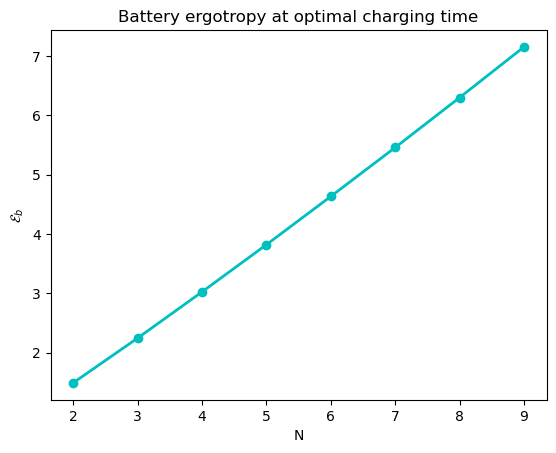

In [24]:
#########################################
# optimal charging time τ (maximum power)
#########################################

τ_list = []

for N in N_arr:
    H, HB, HB_local = central_spin_chain(N, nc, ω, ω0, g)
    
    psi0 = initial_state(N, nc)

    opts = qt.Options(atol=1e-16, rtol=1e-14)        ## ODE solver options
    
    res = qt.sesolve(H, psi0, tlist, e_ops=HB, options=opts)
    
    EB = np.array(res.expect[0])
    
    power = EB / tlist

    τ = tlist[np.argmax(power)]
    
    τ_list.append(τ)

###########################################
# Calculation of ergotropy and fluctuations
###########################################

E_ratio, E_ergo, E_var, F_ratio, FE_ratio = [], [], [], [], []

for i, N in enumerate(N_arr):

    τ = τ_list[i]
    
    H, HB, HB_local = central_spin_chain(N, nc, ω, ω0, g)
    
    psi0 = initial_state(N, nc)
    
    res = qt.sesolve(H, psi0, [0, τ], options=opts)
    
    rho_b = res.states[-1].ptrace(list(range(N)))
    
    r_vals, r_vecs = rho_b.eigenstates()

    # Clip numerical noise to prevent negative probabilities
    r_vals = np.maximum(r_vals, 0) 
    # Renormalize 
    r_vals = r_vals / np.sum(r_vals)
    
    idx = np.argsort(r_vals)[::-1]
    r_vals = r_vals[idx]
    r_vecs = [r_vecs[i] for i in idx]
    
    # Passive Hamiltonian constructed in the passive state's eigenbasis
    
    e_vals, e_vecs = HB_local.eigenstates()
    
    H_passive = sum(e_vals[i] * r_vecs[i] * r_vecs[i].dag() for i in range(len(e_vals)))

    # Ergotropy operator defined w.r.t. passive Hamiltonian
    
    E_op = HB_local - H_passive
    
    E_B = qt.expect(HB_local, rho_b)
    
    E_erg = qt.expect(E_op, rho_b)

    ΔE2 = qt.expect(E_op**2, rho_b) - E_erg**2
    
    ΔE = np.sqrt(qt.expect(E_op**2, rho_b) - E_erg**2)

    Ratio = E_erg / E_B
    
    E_ergo.append(E_erg)

    E_var.append(ΔE2)
        
    E_ratio.append(Ratio)
    
    F_ratio.append(ΔE / E_erg)

    FE_ratio.append(ΔE / E_B)

    print(f"N={N:2d}, τ={τ:.4f}, Eb={E_B:.6f}, Ergotropy={E_erg:.6f}, erg/Eb={Ratio:.12f} Variance={ΔE2:.10e}")


###############################################################
# Plot of battery ergotropy at optimal charging for different N 
###############################################################

plt.plot(N_arr, E_ergo, 'o-', color='c', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b$")
plt.title("Battery ergotropy at optimal charging time")
#plt.savefig("OP1")
plt.show()


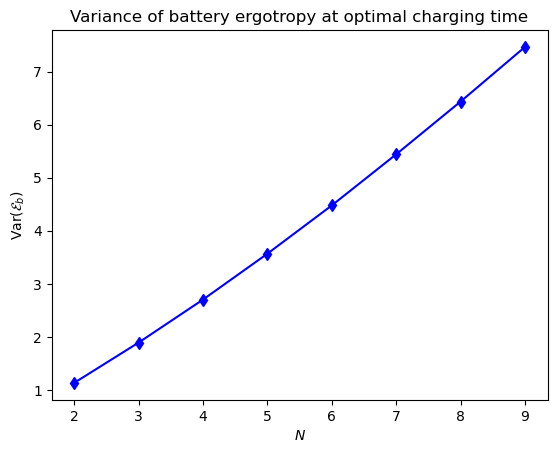

In [25]:
###########################################################################
# Plot of variance of battery ergotropy at optimal charging for different N 
###########################################################################

plt.figure()
plt.plot(N_arr, E_var, 'd-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathrm{Var}(\mathcal{E}_b)$")
plt.title("Variance of battery ergotropy at optimal charging time")
#plt.savefig("OP2")
plt.show()

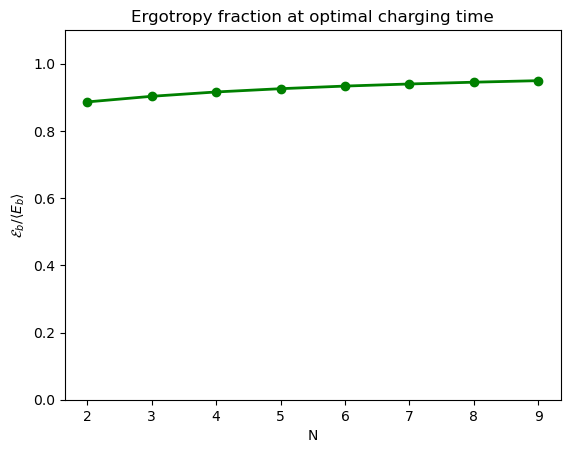

In [26]:
#############################################################
# Plot ergotropy fraction as a function of g for different N 
############################################################
    
plt.plot(N_arr, E_ratio, 'o-', color='g', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b / \langle E_b \rangle$")
plt.ylim(0,1.1)
plt.title("Ergotropy fraction at optimal charging time")
#plt.savefig("OP3")
plt.show()

N= 2, τ=0.2023, Relative Fluctuation =0.712909087622, Relative Fluctuation with Eb =0.631872353645
N= 3, τ=0.1896, Relative Fluctuation =0.612163304111, Relative Fluctuation with Eb =0.552825107249
N= 4, τ=0.1807, Relative Fluctuation =0.543402314140, Relative Fluctuation with Eb =0.497737914028
N= 5, τ=0.1738, Relative Fluctuation =0.494329221040, Relative Fluctuation with Eb =0.457598922665
N= 6, τ=0.1683, Relative Fluctuation =0.456635126118, Relative Fluctuation with Eb =0.426260792908
N= 7, τ=0.1636, Relative Fluctuation =0.427328133618, Relative Fluctuation with Eb =0.401565926751
N= 8, τ=0.1597, Relative Fluctuation =0.402698685779, Relative Fluctuation with Eb =0.380563366773
N= 9, τ=0.1563, Relative Fluctuation =0.382002867804, Relative Fluctuation with Eb =0.362735434486


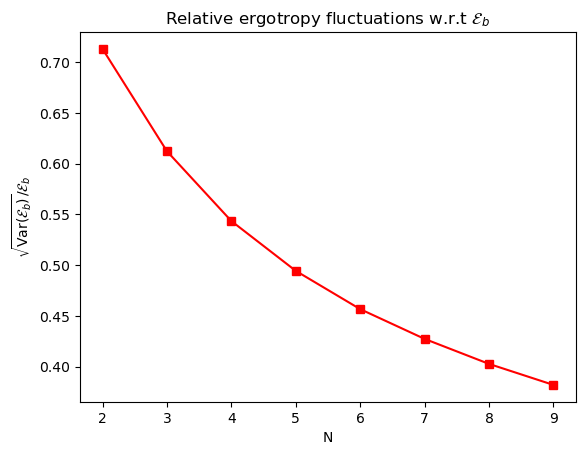

In [27]:
for idx, N in enumerate(N_arr):
    print(f"N={N:2d}, τ={τ_list[idx]:.4f}, Relative Fluctuation ={F_ratio[idx]:.12f}, Relative Fluctuation with Eb ={FE_ratio[idx]:.12f}")


######################################################
# Plot fluctuations as a function of g for different N 
######################################################

plt.plot(N_arr, F_ratio, 's-', color='r')
plt.xlabel("N")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\mathcal{E}_b$")
#plt.savefig("OP4")
plt.show()

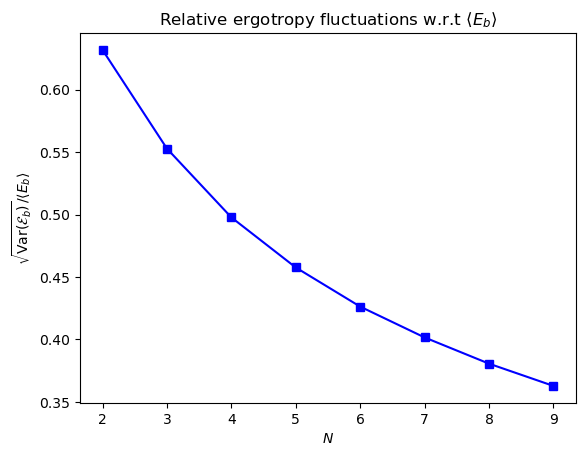

In [28]:
##########################################################################
# Plot fluctuations w.r.t battery energy as function of g for different N 
##########################################################################

plt.figure()
plt.plot(N_arr, FE_ratio, 's-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/ \langle E_b \rangle$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\langle E_b \rangle$")
#plt.savefig("OP5")
plt.show()